### 0. Import dependencies

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

### 1. Creating variables and date

In [37]:
# Step 1: Creating a dataset with 3 independent variables (Features)
np.random.seed(0)
n_samples = 100

# Simulating real-world features for a house dataset
house_size = np.linspace(50, 200, n_samples)          # Size in square meters
location_rating = np.random.randint(1, 6, n_samples)    # Location score from 1 to 5
year_built = np.random.randint(1990, 2025, n_samples)   # Year of construction

# Combine features into a 2D Matrix (DataFrame)
X = pd.DataFrame({
    'size': house_size,
    'location': location_rating,
    'year_built': year_built
})

# Generate a synthetic target variable (y = house price) using our features + random noise
y = 1500 * house_size + 5000 * location_rating + 200 * (year_built - 1990) + np.random.normal(0, 5000, n_samples)

### 2. Splitting the data - training and test

In [38]:
# Step 2: Splitting the data into training and testing sets (80% train, 20% test)
# The function automatically handles the 2D matrix structure of X
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### 3. Implementing linear regression model

In [39]:
# Step 3: Implementing Multiple Linear Regression
model = LinearRegression()

# Train the model using the training data
# NOTE: No .reshape(-1, 1) is required here because a pandas DataFrame is already a 2D array
model.fit(X_train, y_train)

LinearRegression()

### 4. Actual predictions on test data

In [40]:
# Step 4: Making predictions on the test data
y_pred = model.predict(X_test)

#### Creating the Comparison DataFrame

It's a good practice to explicitly create the `comparison` DataFrame that holds the actual and predicted values. This makes the data flow clearer and ensures that subsequent cells relying on `comparison` have a defined source.

In [43]:
# Create a DataFrame to compare actual vs. predicted values
comparison = pd.DataFrame({'Actual Price': y_test, 'Predicted Price': y_pred})

# Display the first few rows of the comparison
print("Comparison of Actual vs. Predicted Prices (first 5 rows):")
print(comparison.head().to_string())

Comparison of Actual vs. Predicted Prices (first 5 rows):
    Actual Price  Predicted Price
0  285586.115170    287352.289379
1  198644.257177    203596.512839
2  268989.207070    263382.986908
3  203024.978384    206409.205863
4  181782.951679    182954.490082


### 5. Results on testing

In [41]:
# Create a copy and round the values for readability
comparison_clean = comparison.copy()
comparison_clean['Actual Price'] = comparison_clean['Actual Price'].round(0)
comparison_clean['Predicted Price'] = comparison_clean['Predicted Price'].round(0)

# Calculate the difference (Error)
comparison_clean['Difference'] = (comparison_clean['Actual Price'] - comparison_clean['Predicted Price']).round(0)

# Show the results
print(comparison_clean.head().to_string())

         size  location  year_built  Actual Price  Predicted Price  Difference
0  175.757576         4        2010      285586.0         287352.0     -1766.0
1  130.303030         1        2021      198644.0         203597.0     -4953.0
2  156.060606         5        2012      268989.0         263383.0      5606.0
3  118.181818         5        2011      203025.0         206409.0     -3384.0
4  116.666667         1        2019      181783.0         182954.0     -1171.0


#### Model Evaluation

After making predictions, it's crucial to evaluate the model's performance using appropriate metrics. For regression, common metrics include Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R-squared (R2 Score). These metrics quantify how well your model's predictions match the actual values.

In [44]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse) # RMSE is the square root of MSE
r2 = r2_score(y_test, y_pred)

print(f"\n--- Model Evaluation Metrics ---")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2 Score): {r2:.4f}")


--- Model Evaluation Metrics ---
Mean Absolute Error (MAE): 3239.79
Mean Squared Error (MSE): 18999803.96
Root Mean Squared Error (RMSE): 4358.88
R-squared (R2 Score): 0.9954


#### Explaining the evaluation metrics:

*   **Mean Absolute Error (MAE):** This is the average of the absolute differences between predictions and actual values. It gives an idea of the typical magnitude of errors.
*   **Mean Squared Error (MSE):** This is the average of the squared differences. It penalizes larger errors more heavily than MAE.
*   **Root Mean Squared Error (RMSE):** This is the square root of MSE. It's often preferred because it's in the same units as the target variable, making it easier to interpret.
*   **R-squared (R2 Score):** This represents the proportion of variance in the dependent variable that can be predicted from the independent variables. An R2 score of 1 indicates a perfect fit, while 0 indicates the model explains none of the variance.

### 6. Plotting the data for visual representation

The first plot shows how closely our predicted prices align with the actual prices. The red dashed line represents a perfect prediction. The closer the blue dots are to this line, the better our model performs.

The second plot, a histogram of the differences, helps us understand the distribution of errors. Ideally, this distribution should be centered around zero and resemble a normal distribution, indicating that the model's errors are random and unbiased.

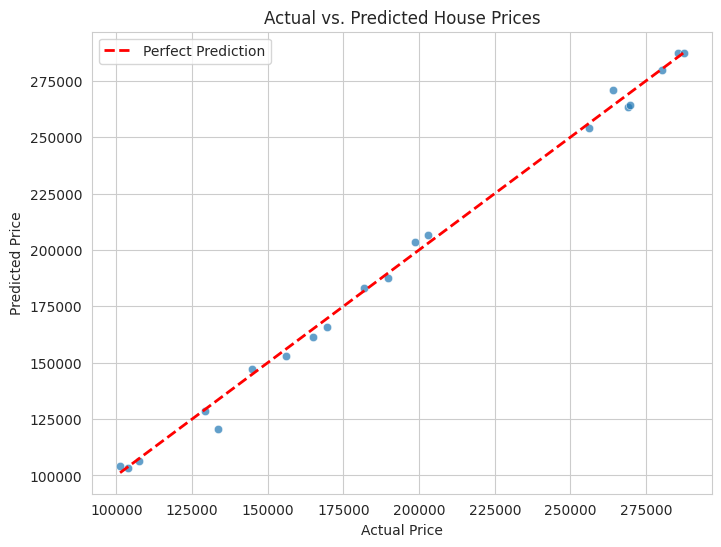

In [42]:
# Set a style for the plots for better aesthetics
sns.set_style("whitegrid")

# Create a figure with a single subplot
fig, axes = plt.subplots(1, 1, figsize=(8, 6))

# Plot: Actual vs. Predicted Prices
sns.scatterplot(x='Actual Price', y='Predicted Price', data=comparison_clean, ax=axes, alpha=0.7)
axes.plot([comparison_clean['Actual Price'].min(), comparison_clean['Actual Price'].max()],
             [comparison_clean['Actual Price'].min(), comparison_clean['Actual Price'].max()],
             color='red', linestyle='--', lw=2, label='Perfect Prediction')
axes.set_title('Actual vs. Predicted House Prices')
axes.set_xlabel('Actual Price')
axes.set_ylabel('Predicted Price')
axes.legend()

plt.show()